# Data quality in AMP hemolysis classification

The companion to the MIC data-quality notebook (`data_quality_mic.ipynb`), for the second task in the thesis: predicting whether a peptide is **hemolytic** (toxic to red blood cells) or not.

The same question applies, is accuracy limited by the model or by the data? For hemolysis the answer is sharper, because the binary label is itself manufactured:

- The raw measurement is continuous (what percent of red blood cells lyse, at what concentration). A peptide is called *hemolytic* or *not* by **thresholding** those continuous values.
- The same peptide, measured more than once, often ends up with **contradictory labels**. About a third of all repeatedly-measured sequences disagree with themselves.

That label noise is an upper bound on any classifier's accuracy. No architecture can be right about a sequence whose ground truth says both yes and no. This notebook shows it, using only data in this repo.

The plotting and number-crunching live in `nb_utils.py`, so the cells below stay at the level of variables and named calls.

Two datasets are compared throughout:
- **WhiteLab**, binary hemolysis labels taken as-is from the source.
- **Threshold**, labels derived in this project by thresholding continuous activity/concentration measurements (the scheme of Timmons and Hewage, 2020).

In [1]:
import sys
from pathlib import Path

# Make nb_utils importable whether this runs from the repo root or from notebooks/.
for _cand in (Path.cwd(), Path.cwd() / "notebooks"):
    if (_cand / "nb_utils.py").exists() and str(_cand) not in sys.path:
        sys.path.insert(0, str(_cand))
from nb_utils import *

REPO = find_repo_root()
datasets = load_hemo_datasets(REPO)

for name, df in datasets.items():
    print(f"{name:10s}: {len(df):5d} measurements, {df['sequence'].nunique():5d} unique sequences")

WhiteLab  :  8823 measurements,  5746 unique sequences
Threshold :  6634 measurements,  4209 unique sequences


## 1. The two datasets at a glance

Class balance and peptide length. Both datasets lean non-hemolytic, WhiteLab strongly so (about 80/20), Threshold less (about 64/36). Peptide length is unimodal around 14 residues in both.

The imbalance matters for how the results are read: a model that always predicts the majority class already reaches the accuracy shown in each panel title (about 80% for WhiteLab). Raw accuracy flatters a hemolysis classifier, so the base rate has to be kept in mind.

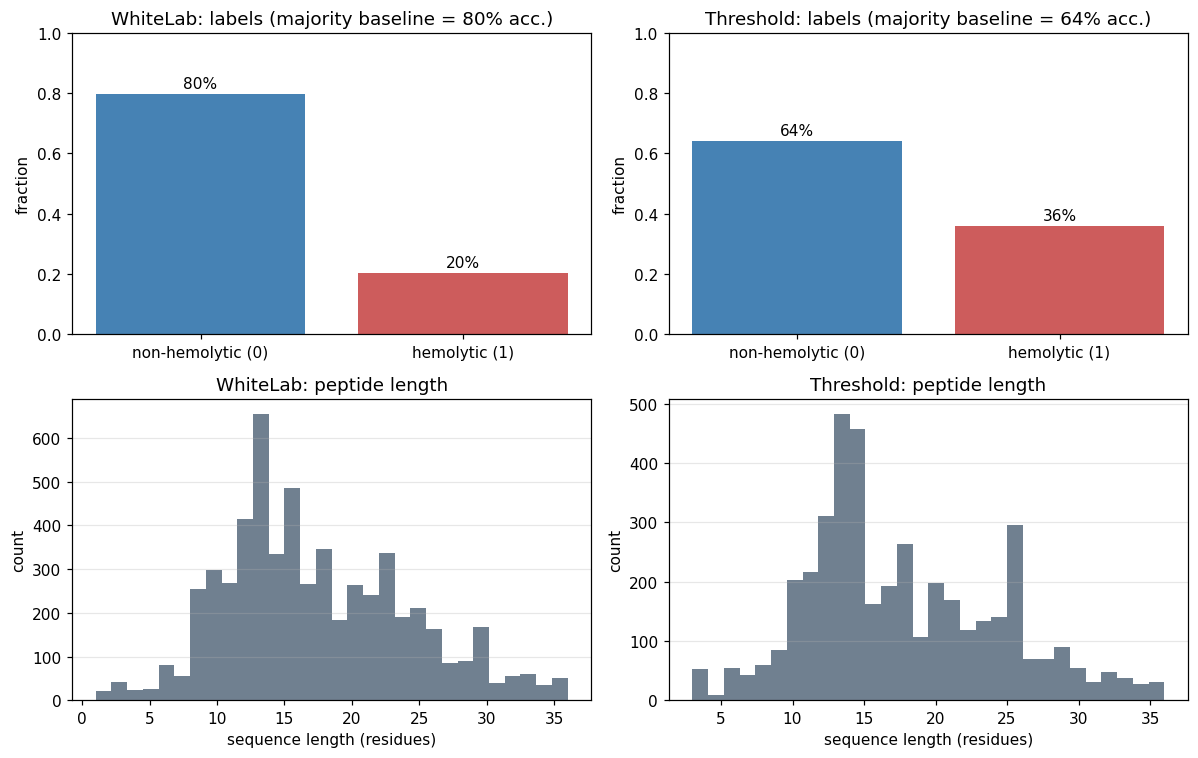

In [2]:
plot_label_and_length(datasets)

## 2. How a binary label is made: thresholding

The Threshold dataset starts from two continuous measurements per assay: the **concentration** tested and the **percent of red blood cells lysed** at that concentration. A peptide is called hemolytic only if it lyses enough cells at a low enough dose. That rule (Timmons and Hewage, 2020) is a set of cutoffs in the (concentration, percent) plane.

The plot below shows every measurement, colored by the label the rule assigns. The two classes are not cleanly separable: near the cutoffs, near-identical measurements fall on opposite sides. A hard 0/1 label hides how close many peptides are to the boundary.

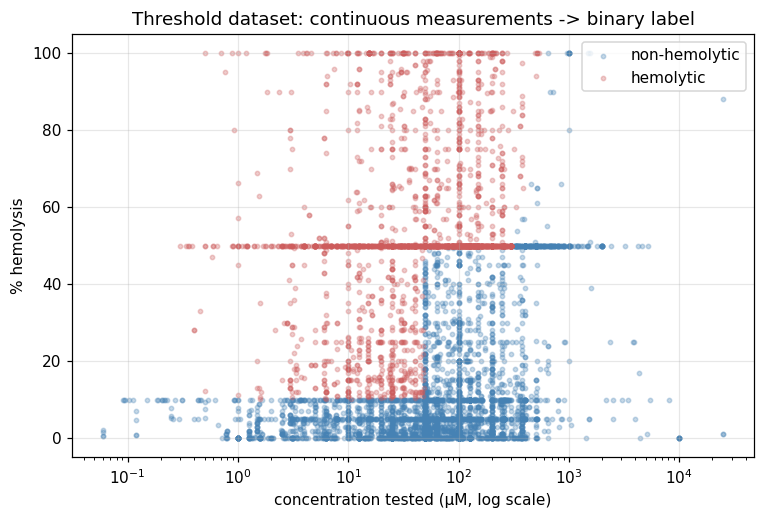

In [3]:
plot_thresholding(datasets["Threshold"])

## 3. The same peptide, measured more than once

As with MIC, many sequences appear several times. Those replicates are where the labels can be checked against each other.

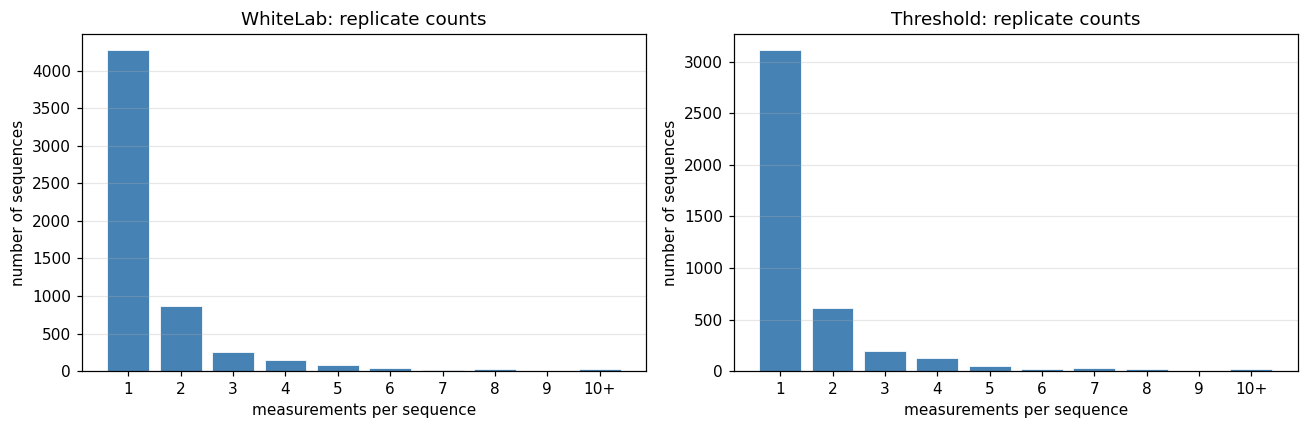

In [4]:
plot_replicate_counts_hemo(datasets)

## 4. Label consistency: the classification noise floor

For every sequence measured at least twice, do its labels agree? A sequence is **inconsistent** if it was called both hemolytic and non-hemolytic in different measurements. Those sequences are unlearnable, the ground truth contradicts itself. The inconsistent share is a hemolysis analog of the MIC measurement-noise floor: a hard ceiling on achievable accuracy.

WhiteLab  : 1475 replicated sequences, 449 inconsistent (30.4%)
Threshold : 1099 replicated sequences, 391 inconsistent (35.6%)


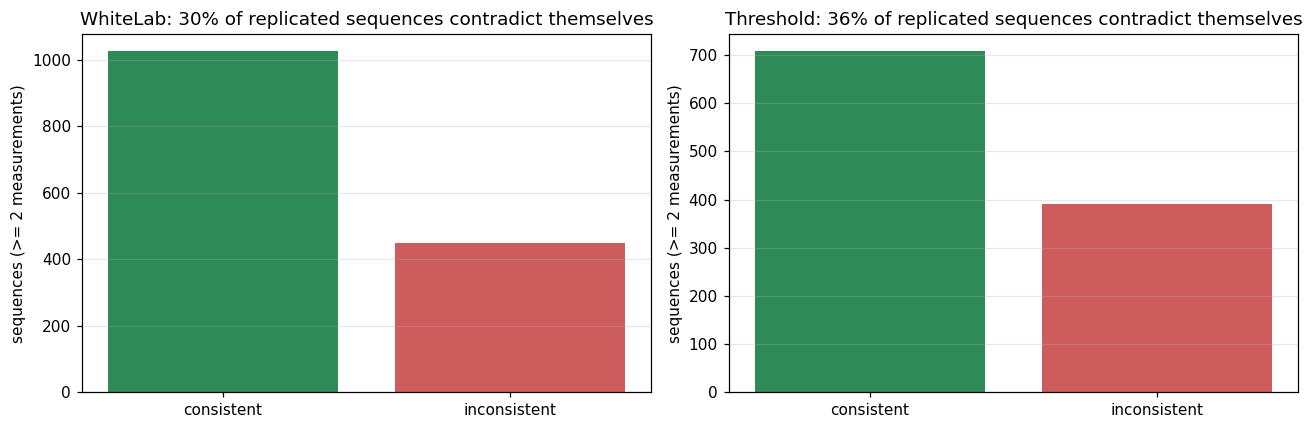

In [5]:
for name, df in datasets.items():
    c = label_consistency(df)
    print(f"{name:10s}: {c['n_replicated']} replicated sequences, "
          f"{c['n_inconsistent']} inconsistent ({c['frac_inconsistent']:.1%})")

plot_label_consistency(datasets)

## Takeaways

- The hemolysis label is a **thresholded** version of noisy continuous measurements. Near the cutoffs, near-identical assays land on opposite sides of the 0/1 line.
- Among sequences measured more than once, **about 30% (WhiteLab) and 36% (Threshold) carry contradictory labels**. No classifier can be right on those, the ground truth disagrees with itself.
- The classes are also imbalanced (about 80/20 and 64/36), so a do-nothing model that always predicts non-hemolytic already scores that as accuracy. Accuracy alone hides both the labeling noise and the base rate.
- So a hemolysis classifier that tops out well below perfect accuracy is not necessarily a weak model, it is bumping into a **labeling-noise ceiling** set by the data and the thresholding step.
- This mirrors the MIC story in `data_quality_mic.ipynb`: clean, honestly-split data exposes where the real limit is. Data quality, not architecture, is the binding constraint. MIC is capped by measurement noise on a continuous target, hemolysis by label noise from thresholding.